## Physics-informed neural network (PINN)

### Train PINN model

#### Check GPU settings for NN training

In [1]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("GPU Devices:", tf.config.list_physical_devices('GPU'))


Num GPUs Available:  0
GPU Devices: []


Testing configuration: neurons=64, batch_size=16, learning_rate=0.001
Fold 1, Epoch 0, Loss: 0.391661
Fold 1, Epoch 50, Loss: 0.035446
Fold 1, Epoch 100, Loss: 0.007320
Fold 1, Epoch 150, Loss: 0.003646
Fold 1, Epoch 200, Loss: 0.002787
Fold 1, Epoch 250, Loss: 0.002111
Fold 1, Epoch 300, Loss: 0.001532
Fold 1, Epoch 350, Loss: 0.001054
Fold 1, Epoch 400, Loss: 0.000684
Fold 1, Epoch 450, Loss: 0.000428
Fold 1, Epoch 500, Loss: 0.000294
Fold 1, Epoch 550, Loss: 0.000239
Fold 1, Epoch 600, Loss: 0.000215
Fold 1, Epoch 650, Loss: 0.000197
Fold 1, Epoch 700, Loss: 0.000182
Fold 1, Epoch 750, Loss: 0.000170
Fold 1, Epoch 800, Loss: 0.000159
Fold 1, Epoch 850, Loss: 0.000150
Fold 1, Epoch 900, Loss: 0.000142
Fold 1, Epoch 950, Loss: 0.000136
Fold 1, Epoch 1000, Loss: 0.000133
Fold 1, Epoch 1050, Loss: 0.000130
Fold 1, Epoch 1100, Loss: 0.000129
Fold 1, Epoch 1150, Loss: 0.000128
Fold 1 early stopped at epoch 1167
Fold 2, Epoch 0, Loss: 0.406798
Fold 2, Epoch 50, Loss: 0.050287
Fold 2, Epoch

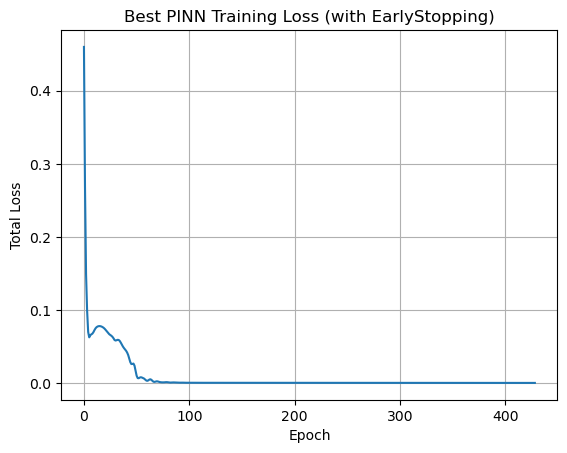

Best Configuration: {'neurons': 64, 'batch_size': 64, 'learning_rate': 0.01}
Best MSE: 9.124899310138283e-05


In [10]:

import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import random
import os
from sklearn.metrics import mean_squared_error

# ===============================
# Reproducibility
# ===============================
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

# ===============================
# Load and preprocess the data
# ===============================
data = pd.read_csv('prepared_data_1hr.csv', index_col=[0])
timestep = 3600
data['time'] = (data['time'] // timestep) * timestep
data = data.groupby('time').last()

features = ['tesBed.uModActual.y', 'tesBed.iceTan.SOC_his1']
target = ['tesBed.iceTan.SOC']
X = data[features].values
Y = data[target].values

# ===============================
# Define custom PINN loss function
# ===============================
def custom_pinn_loss(x, y_true, y_pred, model):
    # Compute raw loss components
    mse_loss = tf.reduce_mean(tf.square(y_true - y_pred))

    with tf.GradientTape() as tape:
        tape.watch(x)
        y_pred_physics = model(x)
    gradients = tape.gradient(y_pred_physics, x)

    u = x[:, 0]
    dSOC_du = gradients[:, 0]

    physics_loss_charge = tf.reduce_mean(tf.square(tf.minimum(dSOC_du[u == -1], 0.0)))  # ∂SOC/∂u ≥ 0 when charging
    physics_loss_discharge = tf.reduce_mean(tf.square(tf.maximum(dSOC_du[u == 1], 0.0)))  # ∂SOC/∂u ≤ 0 when discharging
    physics_loss_zero_mode = tf.reduce_mean(tf.square(dSOC_du[(u == 0) | (u == 2)]))  # ∂SOC/∂u = 0 when idle/chiller

    bound_penalty = tf.reduce_mean(tf.square(tf.nn.relu(-y_pred)) + tf.square(tf.nn.relu(y_pred - 1)))  # SOC ∈ [0, 1]

    # Combine all physics-related loss
    total_physics_loss = physics_loss_charge + physics_loss_discharge + physics_loss_zero_mode

    # Normalization factors (epsilon to prevent division by zero)
    eps = 1e-8
    mse_scale = tf.stop_gradient(tf.abs(mse_loss)) + eps
    physics_scale = tf.stop_gradient(tf.abs(total_physics_loss)) + eps
    bound_scale = tf.stop_gradient(tf.abs(bound_penalty)) + eps

    # Normalize each component
    norm_mse_loss = mse_loss / mse_scale
    norm_physics_loss = total_physics_loss / physics_scale
    norm_bound_penalty = bound_penalty / bound_scale

    # Final weighted sum (weights are now more interpretable)
    total_loss = (
        1.0 * mse_loss +
        0.01 * total_physics_loss +
        1.0 * bound_penalty
    )

    return total_loss


# ===============================
# Define model constructor
# ===============================
def build_model(input_shape, neurons=64, l2_lambda=0.01):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(neurons, activation='relu', input_shape=input_shape, kernel_regularizer=tf.keras.regularizers.L2(l2_lambda)), # first hidden layer
        #tf.keras.layers.Dense(neurons, activation='relu', kernel_regularizer=tf.keras.regularizers.L2(l2_lambda)), # second hidden layer
        #tf.keras.layers.Dense(1, activation='sigmoid') # hard constraints to bound output between 0 and 1; Note: sigmoid is hard to train with PINNs
        tf.keras.layers.Dense(1, activation=None), # output layer
        tf.keras.layers.Lambda(lambda x: tf.clip_by_value(x, 0.0, 1.0)) # hard constraints to bound output between 0 and 1
        #tf.keras.layers.Lambda(lambda x: tf.nn.relu6(x) / 6)
        # note: tf.clip_by_value as the final output outperforms tf.nn.relu6(x) / 6 and tf.nn.sigmoid(x) in this case in terms of CV(RMSE) for whole training dataset

    ])
    return model

# ===============================
# K-Fold Cross Validation + Random Search + EarlyStopping
# ===============================
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {
    'neurons': [64],
    'batch_size': [16, 32, 64], # 16, 32, 64
    'learning_rate': [0.001, 0.01, 0.1], # 0.01, 0.1
}
epochs = 2000
earlystop_patience = 50
best_score = float('inf')
best_model = None
best_params = {}
train_losses = []

# Loop over all combinations of hyperparameters
for neurons in param_grid['neurons']:
    for batch_size in param_grid['batch_size']:
        for learning_rate in param_grid['learning_rate']:
            print(f"Testing configuration: neurons={neurons}, batch_size={batch_size}, learning_rate={learning_rate}")
            fold_scores = []
            for fold, (train_idx, val_idx) in enumerate(kfold.split(X)):
                x_train, x_val = X[train_idx], X[val_idx]
                y_train, y_val = Y[train_idx], Y[val_idx]

                model = build_model((x_train.shape[1],), neurons)
                optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

                # Convert to tensors
                x_train_tensor = tf.convert_to_tensor(x_train, dtype=tf.float32)
                y_train_tensor = tf.convert_to_tensor(y_train, dtype=tf.float32)
                x_val_tensor = tf.convert_to_tensor(x_val, dtype=tf.float32)
                y_val_tensor = tf.convert_to_tensor(y_val, dtype=tf.float32)

                # Training with early stopping
                losses = []
                best_loss = np.inf
                patience_counter = 0
                for epoch in range(epochs):
                    with tf.GradientTape() as tape:
                        y_pred = model(x_train_tensor, training=True)
                        loss = custom_pinn_loss(x_train_tensor, y_train_tensor, y_pred, model)
                    gradients = tape.gradient(loss, model.trainable_variables)
                    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
                    losses.append(loss.numpy())

                    # Early stopping check
                    if loss.numpy() < best_loss - 1e-6:
                        best_loss = loss.numpy()
                        patience_counter = 0
                    else:
                        patience_counter += 1
                        if patience_counter >= earlystop_patience:
                            print(f"Fold {fold+1} early stopped at epoch {epoch}")
                            break

                    if epoch % 50 == 0:
                        print(f"Fold {fold+1}, Epoch {epoch}, Loss: {loss.numpy():.6f}")

                # Evaluate on validation data
                y_val_pred = model(x_val_tensor).numpy().flatten()
                val_score = mean_squared_error(y_val, y_val_pred)
                fold_scores.append(val_score)

            avg_score = np.mean(fold_scores)
            print(f"Average MSE for config: {avg_score}")

            if avg_score < best_score:
                best_score = avg_score
                best_model = model
                best_params = {'neurons': neurons, 'batch_size': batch_size, 'learning_rate': learning_rate}
                print(f"New best model found: {best_params} with MSE {best_score}")
                train_losses = losses

# ===============================
# Save best model and plot training loss
# ===============================
os.makedirs('./results_pinn', exist_ok=True)
best_model.save('./results_pinn/pinn_SOC_model.h5')

plt.plot(train_losses)
plt.xlabel('Epoch')
plt.ylabel('Total Loss')
plt.title('Best PINN Training Loss (with EarlyStopping)')
plt.grid(True)
plt.savefig('./results_pinn/pinn_SOC_loss_curve.png')
plt.show()

print("Best Configuration:", best_params)
print("Best MSE:", best_score)



### PINN Scatter plot

24/24 [==============================] - 4s 913us/step


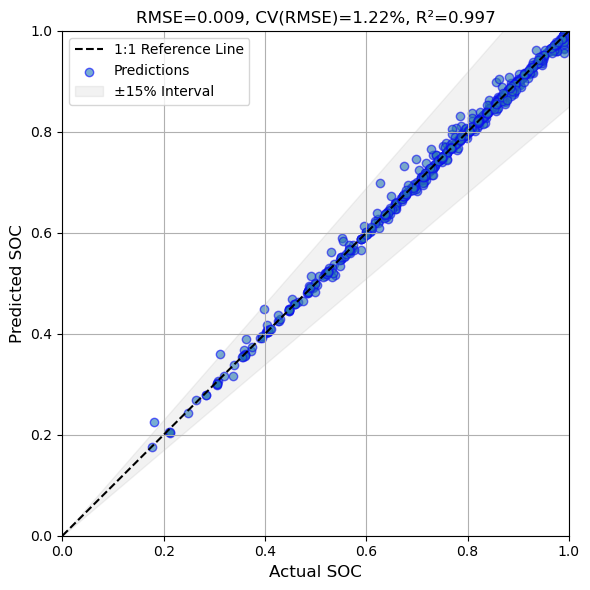

In [12]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# === Load model ===
nn_model = tf.keras.models.load_model('./results_pinn/pinn_SOC_model.h5', compile=False)

# === Load and preprocess data ===
data = pd.read_csv('prepared_data_1hr.csv', index_col=[0])
features = ['tesBed.uModActual.y', 'tesBed.iceTan.SOC_his1']
target = ['tesBed.iceTan.SOC']
X = data[features].values
Y = data[target].values

# === Full Prediction ===
y_pred_full = nn_model.predict(X).flatten()
y_true_full = Y.flatten()

# === Compute metrics ===
rmse_full = np.sqrt(np.mean((y_pred_full - y_true_full) ** 2))
cvrmse_full = (rmse_full / np.mean(y_true_full)) * 100
r2_full = r2_score(y_true_full, y_pred_full)

# === Scatter Plot ===
plt.figure(figsize=(6, 6))
plt.scatter(y_true_full, y_pred_full, alpha=0.6, edgecolor='blue', label='Predictions')
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='1:1 Reference Line')
plt.fill_between([0, 1], [0, 0.85], [0, 1.15], color='gray', alpha=0.1, label='±15% Interval')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel('Actual SOC', fontsize=12)
plt.ylabel('Predicted SOC', fontsize=12)
plt.title(f'RMSE={rmse_full:.3f}, CV(RMSE)={cvrmse_full:.2f}%, R²={r2_full:.3f}', fontsize=12)
plt.grid(True)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('./results_pinn/SOC_scatter.png', dpi=300)
plt.show()

### Vanilla NN Scatter plot

24/24 [==============================] - 0s 2ms/step


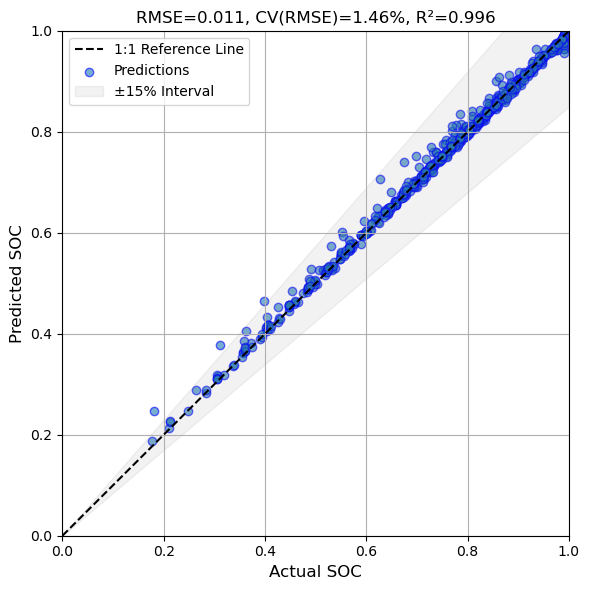

In [69]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# === Load model ===
nn_model = tf.keras.models.load_model('./results_dnn/dnn_SOC_model.h5', compile=False)

# === Load and preprocess data ===
data = pd.read_csv('prepared_data_1hr.csv', index_col=[0])
features = ['tesBed.uModActual.y', 'tesBed.iceTan.SOC_his1']
target = ['tesBed.iceTan.SOC']
X = data[features].values
Y = data[target].values

# === Full Prediction ===
y_pred_full = nn_model.predict(X).flatten()
y_true_full = Y.flatten()

# === Compute metrics ===
rmse_full = np.sqrt(np.mean((y_pred_full - y_true_full) ** 2))
cvrmse_full = (rmse_full / np.mean(y_true_full)) * 100
r2_full = r2_score(y_true_full, y_pred_full)

# === Scatter Plot ===
plt.figure(figsize=(6, 6))
plt.scatter(y_true_full, y_pred_full, alpha=0.6, edgecolor='blue', label='Predictions')
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='1:1 Reference Line')
plt.fill_between([0, 1], [0, 0.85], [0, 1.15], color='gray', alpha=0.1, label='±15% Interval')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel('Actual SOC', fontsize=12)
plt.ylabel('Predicted SOC', fontsize=12)
plt.title(f'RMSE={rmse_full:.3f}, CV(RMSE)={cvrmse_full:.2f}%, R²={r2_full:.3f}', fontsize=12)
plt.grid(True)
plt.legend(loc='upper left')
plt.tight_layout()
#plt.savefig('./results_dnn/SOC_scatter_full.png', dpi=300)
plt.show()

## Model Sanity Check

### Time-series plot

1/1 [==============================] - 0s 23ms/step


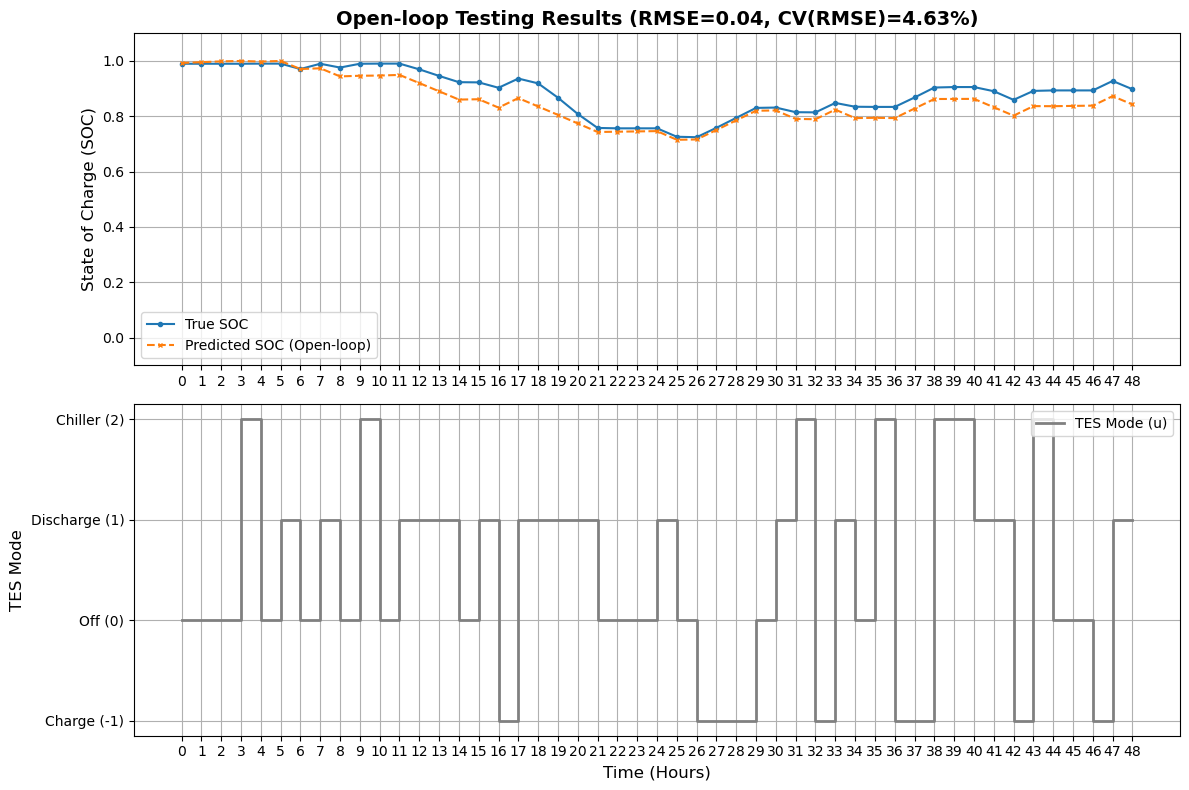

1/1 [==============================] - 0s 21ms/step


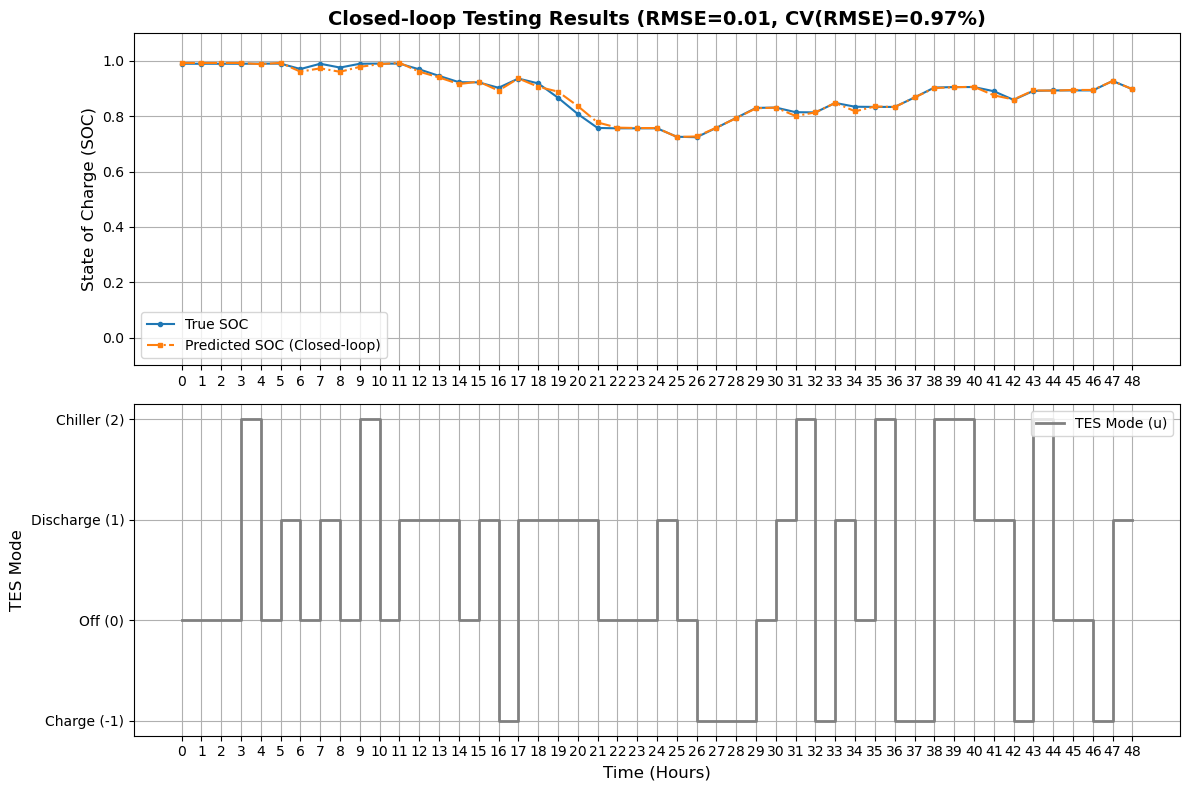

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === Open-loop & Closed-loop Testing ===
#nn_model = model
nn_model = tf.keras.models.load_model('./results_pinn/pinn_SOC_model.h5', compile=False)

# ===============================
# Load and preprocess the data
# ===============================
data = pd.read_csv('prepared_data_1hr.csv', index_col=[0])
timestep = 3600
data['time'] = (data['time'] // timestep) * timestep
data = data.groupby('time').last()

features = ['tesBed.uModActual.y', 'tesBed.iceTan.SOC_his1']
target = ['tesBed.iceTan.SOC']

updated_var_index = features.index('tesBed.iceTan.SOC_his1')

X = data[features].values
Y = data[target].values

# Determine dataset split point for testing purposes
split_point = int(0.5 * len(X))
x_test = X[split_point:]
y_test = Y[split_point:]


start_step = 0
num_days = 2
steps_per_day = 24
total_steps = num_days * steps_per_day + 1
if start_step + total_steps > len(x_test):
    raise ValueError("Not enough data points for multi-day test.")

y_open_loop = []
y_true = []
predicted_SOC = x_test[start_step, updated_var_index]

for step in range(total_steps):
    current_input = x_test[start_step + step:start_step + step + 1].copy()
    current_input[0, updated_var_index] = predicted_SOC
    predicted_SOC = nn_model.predict(current_input)[0][0]
    y_open_loop.append(predicted_SOC)
    y_true.append(y_test[start_step + step][0])

y_open_loop = np.array(y_open_loop)
y_true = np.array(y_true)
rmse_open_loop = np.sqrt(np.mean((y_open_loop - y_true) ** 2))
cvrmse_open_loop = (rmse_open_loop / np.mean(y_true)) * 100

# Extract operational mode (first input variable) for plotting
u_sequence = x_test[start_step:start_step + total_steps, 0]

steps_per_hour = 1
hourly_indices = np.arange(0, total_steps, steps_per_hour)
hour_labels = np.arange(total_steps)

# === Open-loop SOC + Operational Mode Plot ===
plt.figure(figsize=(12, 8))

# Subplot 1: SOC predictions vs truth
plt.subplot(2, 1, 1)
plt.plot(y_true, label='True SOC', marker='o', markersize=3)
plt.plot(y_open_loop, label='Predicted SOC (Open-loop)', linestyle='--', marker='x', markersize=3)
plt.xticks(hourly_indices, hour_labels)
plt.ylabel('State of Charge (SOC)', fontsize=12)
plt.ylim(-0.1, 1.1)
plt.title(f'Open-loop Testing Results (RMSE={rmse_open_loop:.2f}, CV(RMSE)={cvrmse_open_loop:.2f}%)', fontsize=14, fontweight='bold')
plt.grid(True)
plt.legend(loc='lower left')

# Subplot 2: Operational mode
plt.subplot(2, 1, 2)
plt.step(range(total_steps), u_sequence, where='pre', color='gray', label='TES Mode (u)', linewidth=2) # where='pre' or 'mid' or 'post'
plt.yticks([-1, 0, 1, 2], ['Charge (-1)', 'Off (0)', 'Discharge (1)', 'Chiller (2)'])
plt.ylabel('TES Mode', fontsize=12)
plt.xticks(hourly_indices, hour_labels)
plt.xlabel('Time (Hours)', fontsize=12)
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('./results_pinn/open_loop_test_SOC.png', dpi=300)
plt.show()

# === Closed-loop SOC + Operational Mode Plot ===
y_closed_loop = []
for step in range(total_steps):
    current_input = x_test[start_step + step:start_step + step + 1].copy()
    predicted_SOC = nn_model.predict(current_input)[0][0]
    y_closed_loop.append(predicted_SOC)

y_closed_loop = np.array(y_closed_loop)
rmse_closed_loop = np.sqrt(np.mean((y_closed_loop - y_true) ** 2))
cvrmse_closed_loop = (rmse_closed_loop / np.mean(y_true)) * 100


plt.figure(figsize=(12, 8))
# Subplot 1: SOC predictions vs truth
plt.subplot(2, 1, 1)
plt.plot(y_true, label='True SOC', marker='o', markersize=3)
plt.plot(y_closed_loop, label='Predicted SOC (Closed-loop)', linestyle='-.', marker='s', markersize=3)
plt.xticks(hourly_indices, hour_labels)
plt.ylabel('State of Charge (SOC)', fontsize=12)
plt.ylim(-0.1, 1.1)
plt.title(f'Closed-loop Testing Results (RMSE={rmse_closed_loop:.2f}, CV(RMSE)={cvrmse_closed_loop:.2f}%)', fontsize=14, fontweight='bold')
plt.grid(True)
plt.legend(loc='lower left')

# Subplot 2: Operational mode
plt.subplot(2, 1, 2)
plt.step(range(total_steps), u_sequence, where='pre', color='gray', label='TES Mode (u)', linewidth=2)
plt.yticks([-1, 0, 1, 2], ['Charge (-1)', 'Off (0)', 'Discharge (1)', 'Chiller (2)'])
plt.xticks(hourly_indices, hour_labels)
plt.ylabel('TES Mode', fontsize=12)
plt.xlabel('Time (Hours)', fontsize=12)
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('./results_pinn/closed_loop_test_SOC.png', dpi=300)
plt.show()


### SHAR Explanation

2/2 [==============================] - 0s 7ms/step


  0%|          | 0/100 [00:00<?, ?it/s]

4/4 [==============================] - 0s 2ms/step


  1%|          | 1/100 [00:00<00:19,  5.02it/s]

4/4 [==============================] - 0s 2ms/step


...

 98%|█████████▊| 98/100 [00:18<00:00,  5.91it/s]

4/4 [==============================] - 0s 3ms/step


 99%|█████████▉| 99/100 [00:18<00:00,  6.03it/s]

4/4 [==============================] - 0s 1ms/step


100%|██████████| 100/100 [00:18<00:00,  5.43it/s]


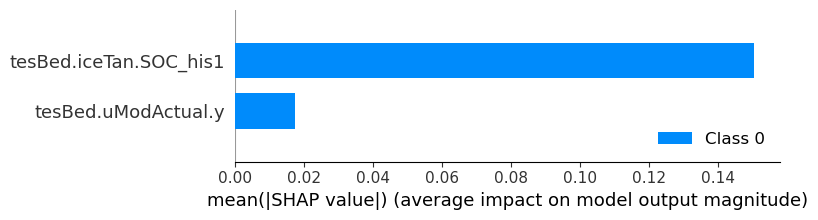

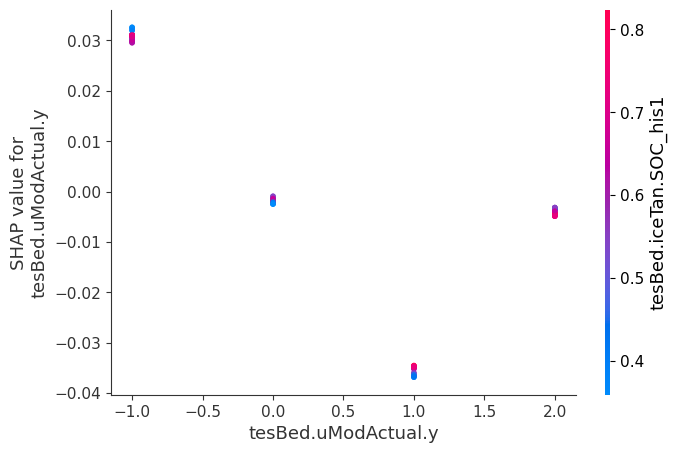

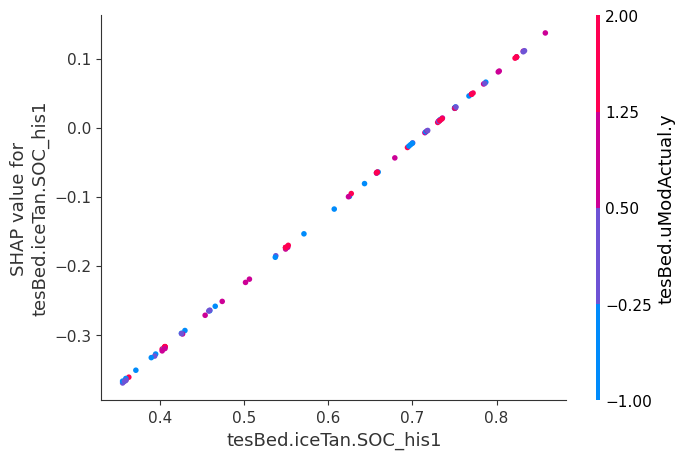

In [4]:
import shap
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# === Load model ===
model = tf.keras.models.load_model('./results_pinn/pinn_SOC_model.h5', compile=False)

# === Load data ===
data = pd.read_csv('prepared_data_1hr.csv', index_col=[0])
features = ['tesBed.uModActual.y', 'tesBed.iceTan.SOC_his1']
target = ['tesBed.iceTan.SOC']
X = data[features].values
Y = data[target].values

# === SHAP Explanation ===
# Use KernelExplainer for broader compatibility (more stable for complex models)
explainer = shap.KernelExplainer(model.predict, X[:50])  # use a small background sample
shap_values = explainer.shap_values(X[:100])  # explain a sample subset

# === SHAP Summary Plot ===
shap.summary_plot(shap_values, X[:100], feature_names=features)

# === SHAP Dependence Plots ===
for i, feature in enumerate(features):
    shap.dependence_plot(i, shap_values[0], X[:100], feature_names=features)

